# Visualizing epistemic_calibration as a confidence x consensus grid

`epistemic_calibration` makes two independent judgments per claim -- how
confidently it's *phrased* (high/moderate/low) and what the literature says
its *actual* status is (established/contested/uncertain) -- then looks the
pair up in a fixed 3x3 scoring table. That table is asymmetric on purpose:
overconfidence (stated as fact, but the literature has nothing on it) is
penalized harder than underconfidence (hedged, but actually well-established),
since the framework treats confident speculation as the more dangerous
failure mode.

This notebook draws that table as a heatmap and plots a hypothesis's actual
claims on top of it -- so instead of "0.44, poorly calibrated" you can *see*
which cell(s) the claims are landing in, and whether they cluster in the
dangerous high-confidence/uncertain corner.

The heatmap is built from `_CALIBRATION_SCORES`, the real scoring table, and
the plotted points come from actually running `EpistemicCalibration().score()`
-- nothing here is reimplemented.


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "benchmarking_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import numpy as np

from benchmarking_pipeline.axes.accuracy.epistemic_calibration import (
    _CALIBRATION_SCORES,
    _CONFIDENCE_CHOICES,
    _CONSENSUS_CHOICES,
    EpistemicCalibration,
)
from benchmarking_pipeline.core.config import RunConfig
from benchmarking_pipeline.core.context import Context
from benchmarking_pipeline.core.models import EvaluationRun, Tool
from benchmarking_pipeline.io.parsers import parse_json
from benchmarking_pipeline.services.literature import CompositeLiteratureClient
from benchmarking_pipeline.services.llm_judge import OpenAIJudge

# --- Config ---
CAPTURE_PATH = "data/captures/dmri_extracted.json"
HYPOTHESIS_RANK = 1
JUDGE_MODEL = "gpt-4o-mini"
LITERATURE_MAILTO = None  # optional: your email, for CrossRef's polite pool

hyps = parse_json(CAPTURE_PATH).hypotheses
hyp = next(h for h in hyps if h.rank == HYPOTHESIS_RANK)
print(f"H{hyp.rank}: {hyp.text}")
print(f"{len(hyp.claims)} claims")


H1: Model-discriminative closed-loop acquisition driven by the PRISM posterior
11 claims


## Run the real metric


In [2]:
judge = OpenAIJudge(JUDGE_MODEL)
lit = CompositeLiteratureClient(mailto=LITERATURE_MAILTO)
run = EvaluationRun(tool=Tool(name="notebook"), prompt="", outputs=parse_json(CAPTURE_PATH))
ctx = Context(config=RunConfig(), judge=judge, literature=lit)

result = EpistemicCalibration().score(hyp, run, ctx)
print(f"score: {result.score} ({result.anchor})")
print()
for a in result.evidence["assessed"]:
    print(f"[{a['expressed']:8} x {a['actual']:11} -> {a['calibration']:.1f}]  {a['claim'][:90]}")
if result.evidence["unassessed"]:
    print()
    print("Unassessed (no literature found):")
    for u in result.evidence["unassessed"]:
        print(f"  [{u['expressed']}]  {u['claim'][:90]}")


score: 0.5273 (poorly calibrated)

[moderate x uncertain   -> 0.6]  Existing experimental design methods for diffusion MRI optimize acquisition for parameter 
[high     x uncertain   -> 0.0]  Previous work on model-discriminative experimental design in dMRI (such as by Basser 2008 
[high     x contested   -> 0.4]  No existing method for model selection in diffusion MRI uses a closed-loop process that le
[low      x uncertain   -> 1.0]  Given PRISM's joint posterior over model structure (M) and parameters (θ) after t measurem
[high     x uncertain   -> 0.0]  Because the PRISM inference is amortized, the expected information gain for candidate meas
[high     x uncertain   -> 0.0]  This approach transforms model selection from a passive procedure (fitting all models to a
[moderate x uncertain   -> 0.6]  For new tissue types with unknown optimal compartment sets, adaptive closed-loop acquisiti
[moderate x uncertain   -> 0.6]  A key empirical test is whether this entropy-based active acquis

## The scoring table, with this hypothesis's claims plotted on top

Background color = the real, fixed calibration score for that (expressed,
actual) combination -- green is good, red is the worst case (confidently
stated, but the literature has nothing on it). Each dot is one assessed
claim, jittered so claims landing in the same cell don't overlap exactly.
Unassessed claims (no literature found) aren't plotted -- there's no
"actual consensus" axis position for them.


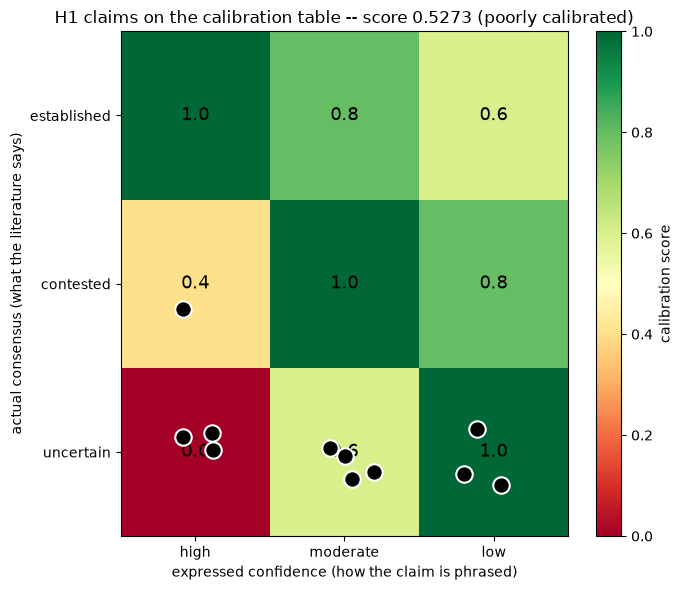

In [3]:
conf_order = _CONFIDENCE_CHOICES  # ["high", "moderate", "low"]
cons_order = _CONSENSUS_CHOICES   # ["established", "contested", "uncertain"]

grid = np.array([[_CALIBRATION_SCORES[(c, a)] for c in conf_order] for a in cons_order])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for yi in range(len(cons_order)):
    for xi in range(len(conf_order)):
        ax.text(xi, yi, f"{grid[yi, xi]:.1f}", ha="center", va="center", fontsize=13)

ax.set_xticks(range(len(conf_order)), conf_order)
ax.set_yticks(range(len(cons_order)), cons_order)
ax.set_xlabel("expressed confidence (how the claim is phrased)")
ax.set_ylabel("actual consensus (what the literature says)")
ax.set_title(f"H{hyp.rank} claims on the calibration table -- score {result.score} ({result.anchor})")

rng = np.random.default_rng(7)
for a in result.evidence["assessed"]:
    x = conf_order.index(a["expressed"]) + rng.uniform(-0.2, 0.2)
    y = cons_order.index(a["actual"]) + rng.uniform(-0.2, 0.2)
    ax.scatter(x, y, s=140, color="black", edgecolors="white", linewidths=1.5, zorder=3)

fig.colorbar(im, ax=ax, label="calibration score")
plt.tight_layout()
plt.show()


## A caveat worth having in view while reading the plot above

The table has no notion of claim *role*. A `prediction`-role claim ("this
should reach confident selection in fewer measurements than any fixed
protocol") is, by construction, a forecast about something not yet tested --
the literature search correctly comes back `uncertain`. If that prediction is
phrased confidently, as hypothesis-generation proposals often are (they're
describing what the method *does*, not hedging about whether it'll work), it
lands in the worst cell (high x uncertain = 0.0) even though this isn't
overconfidence about an established fact, just confident language about a
novel, untested idea. If the dots above cluster in that corner, read it
alongside each claim's role, printed above, before concluding the tool is
genuinely overconfident.
